<a href="https://colab.research.google.com/github/AKBER-HUSSAIN/DL-2026/blob/main/dl_week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3

9. Implement an MLP by varying bias, weights, and learning rate, and record observations for different learning rate values. Plot a graph showing the relationship between loss (error) and learning rate.

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR
y = np.array([[0], [1], [1], [0]])

class MLP:
    def __init__(self, lr, epochs):
        self.lr = lr
        self.epochs = epochs
    def fit(self, X, y):
        np.random.seed(42)  # Same initialization for fair comparison

        # Initialize weights and biases
        w1 = np.random.rand(2, 2)
        b1 = np.random.rand(1, 2)

        w2 = np.random.rand(2, 1)
        b2 = np.random.rand(1, 1)
        for _ in range(self.epochs):
            h1_z = np.dot(X, w1) + b1
            h1_o = sigmoid(h1_z)

            final_input = np.dot(h1_o, w2) + b2
            y_pred = sigmoid(final_input)

            error = y - y_pred
            loss = np.mean(error ** 2)

            # backpropagation
            # dl/dz = dl/dy^ * (dy^/dz) -> sigmoid derivative
            d_output = -2*(error) * sigmoid_derivative(y_pred)
            # d_output.dot(w2.T) -> gradient backpropagated
            d_hidden = d_output.dot(w2.T) * sigmoid_derivative(h1_o)

             # Update weights and biases
             #w(t + 1) = w(t) - lr* (delta(w(t)))
            w2 -= h1_o.T.dot(d_output) * self.lr # h1_o.T - dz\dw -> similarly for other weights and biases
            b2 -= np.sum(d_output, axis=0, keepdims=True) * self.lr

            w1 -= X.T.dot(d_hidden) * self.lr
            b1 -= np.sum(d_hidden, axis=0, keepdims=True) * self.lr
        return loss



In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 10000

for lr in learning_rates:
    perc = MLP(lr, epochs)
    loss = perc.fit(X, y)
    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")


Learning Rate: 0.01, Final Loss: 0.195983
Learning Rate: 0.05, Final Loss: 0.002546
Learning Rate: 0.1, Final Loss: 0.000902
Learning Rate: 0.5, Final Loss: 0.000135
Learning Rate: 1.0, Final Loss: 0.000064


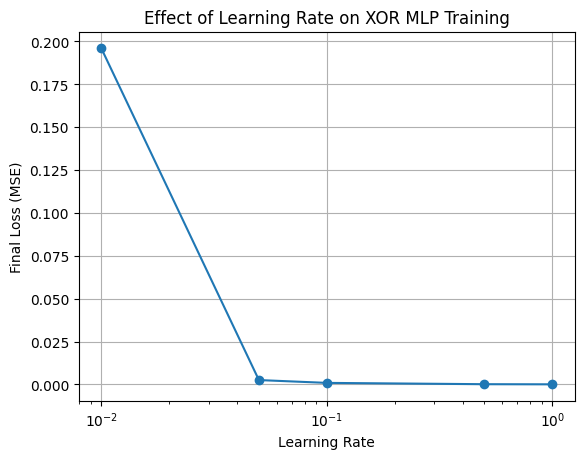

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

10. Implement an MLP using the Gradient Descent algorithm, and analyze the convergence behavior and performance of the network.

Learning Rate: 0.01, Final Loss: 0.269982
Learning Rate: 0.05, Final Loss: 0.249206
Learning Rate: 0.1, Final Loss: 0.248871
Learning Rate: 0.5, Final Loss: 0.241013
Learning Rate: 1.0, Final Loss: 0.198652


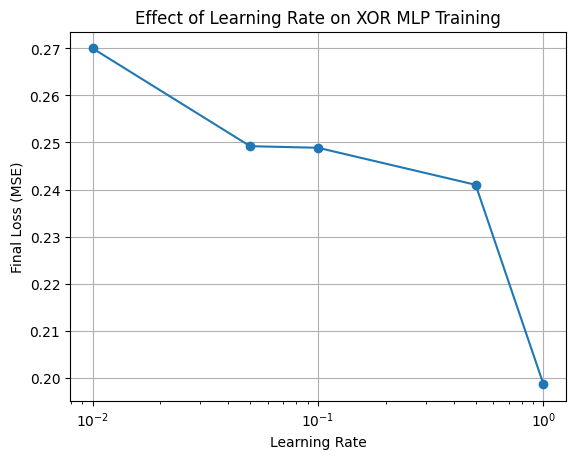

In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 100

for lr in learning_rates:
    perc = MLP(lr, epochs)
    loss = perc.fit(X, y)
    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

import matplotlib.pyplot as plt

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

Learning Rate: 0.01, Final Loss: 0.248861
Learning Rate: 0.05, Final Loss: 0.240611
Learning Rate: 0.1, Final Loss: 0.196214
Learning Rate: 0.5, Final Loss: 0.002551
Learning Rate: 1.0, Final Loss: 0.000903


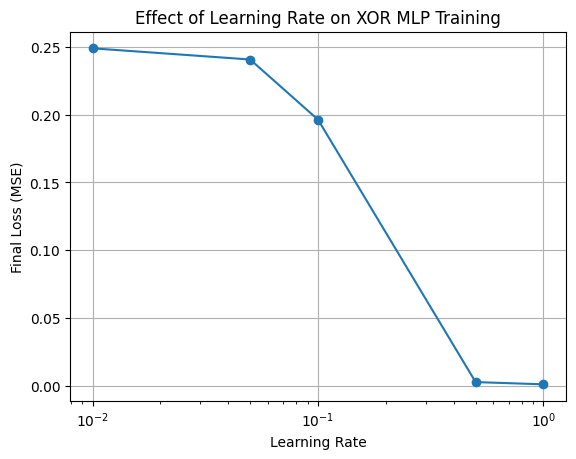

In [ ]:
learning_rates = [0.01, 0.05, 0.1, 0.5, 1.0]
final_losses = []

epochs = 1000

for lr in learning_rates:
    perc = MLP(lr, epochs)
    loss = perc.fit(X, y)
    final_losses.append(loss)
    print(f"Learning Rate: {lr}, Final Loss: {loss:.6f}")

import matplotlib.pyplot as plt

plt.figure()
plt.plot(learning_rates, final_losses, marker='o')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss (MSE)")
plt.title("Effect of Learning Rate on XOR MLP Training")
plt.xscale("log")
plt.grid(True)
plt.show()

Observation on changing epochs: with low epochs for lower learning rate less epochs(100 or 1000) is not sufficient to converge - either increase lr or increase epochs

for higher epochs(10000) model is able to converge with less learning rate as well

11. Implement a Perceptron on IRIS Dataset what are your observations with respect to learning rate using Perceptron class in sklearn. (explore all the parameters of Perceptron class).


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Perceptron()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8


<Axes: >

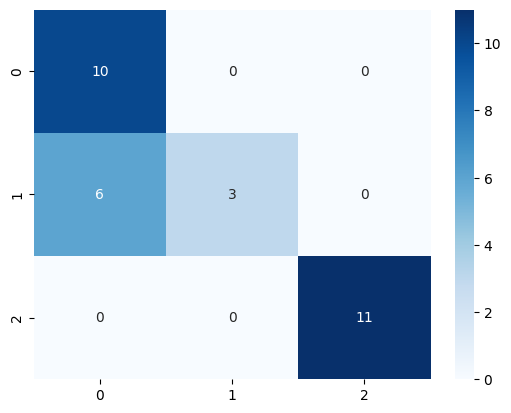

In [ ]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Blues")

12. Implement MLP on any dataset and explore what particular parameters works for it such as learning rate, iterations etc


In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

wine = load_wine()
X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = Perceptron()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.75


<Axes: >

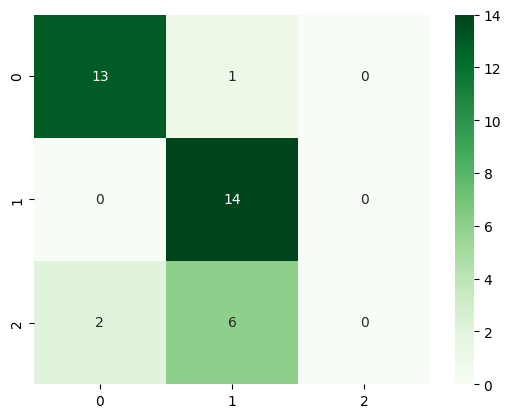

In [ ]:
import seaborn as sns

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap="Greens")

In [ ]:
learning_rates = [0.0001, 0.001, 0.01, 0.1]
epochs = [50, 100, 1000, 10000]

accuracy_matrix = np.zeros((len(learning_rates), len(epochs)))

for i, lr in enumerate(learning_rates):
    for j, ep in enumerate(epochs):
        model = Perceptron(
            eta0=lr,
            max_iter=ep,
            random_state=42,
            tol=None
        )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        accuracy_matrix[i, j] = acc
        print(f"LR={lr}, Epochs={ep}, Accuracy={acc:.4f}")

LR=0.0001, Epochs=50, Accuracy=0.7000
LR=0.0001, Epochs=100, Accuracy=0.7667
LR=0.0001, Epochs=1000, Accuracy=0.7667
LR=0.0001, Epochs=10000, Accuracy=0.7000
LR=0.001, Epochs=50, Accuracy=0.7000
LR=0.001, Epochs=100, Accuracy=0.7667
LR=0.001, Epochs=1000, Accuracy=0.7667
LR=0.001, Epochs=10000, Accuracy=0.7000
LR=0.01, Epochs=50, Accuracy=0.7000
LR=0.01, Epochs=100, Accuracy=0.7667
LR=0.01, Epochs=1000, Accuracy=0.8667
LR=0.01, Epochs=10000, Accuracy=0.7000
LR=0.1, Epochs=50, Accuracy=0.8000
LR=0.1, Epochs=100, Accuracy=0.9000
LR=0.1, Epochs=1000, Accuracy=0.7667
LR=0.1, Epochs=10000, Accuracy=0.7000


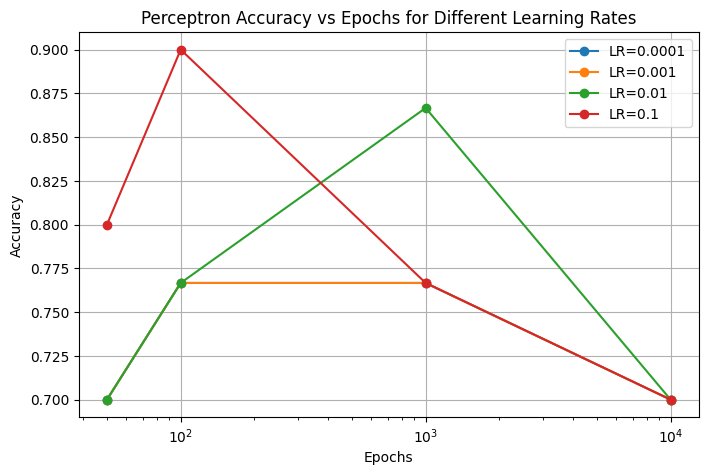

In [ ]:
plt.figure(figsize=(8, 5))

for i, lr in enumerate(learning_rates):
    plt.plot(epochs, accuracy_matrix[i], marker='o', label=f"LR={lr}")

plt.xscale("log")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy vs Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()


13. Implement MLP with appropriate number of hidden layers and perceptrons to learn hand written digit dataset(MNIST).

In [ ]:
from tensorflow.keras.datasets import mnist
from sklearn.neural_network import MLPClassifier


(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()


X_train_full = X_train_full / 255.0
X_test_full  = X_test_full / 255.0


X_train_full = X_train_full.reshape(-1, 28*28)
X_test_full  = X_test_full.reshape(-1, 28*28)

mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=100, verbose=1)

mlp.fit(X_train_full, y_train_full)


In [ ]:
print("Training set score:", mlp.score(X_train_full, y_train_full))
print("Testing set score:", mlp.score(X_test_full, y_test_full))

Training set score: 1.0
Testing set score: 0.9734
